<img align="left" style="padding-right:10px;" src="figuras/banner_cd.png">

# Proyecto de Machine Learning

	
En el mundo de las finanzas, la toma de decisiones relacionada con la aprobación de préstamos bancarios es fundamental para el éxito de las instituciones financieras y la seguridad de los clientes. Uno de los desafíos más cruciales en este contexto es la capacidad de prever con precisión si un individuo será capaz de cumplir con sus obligaciones de pago. Esta tarea adquiere una nueva dimensión en un entorno donde los datos masivos y las complejidades financieras requieren soluciones innovadoras.

El presente proyecto se centra en abordar la problemática de determinar si un solicitante es apto para recibir un préstamo bancario basándose en 20 parámetros, (descritos a continuación). Se utilizarán distintos modelos de Machine Learning para determinar el de mejor desempeño


<center><h1 style="font-size:2em;color:#2467C0">Caso de estudio: German Credit Data </h1></center>
<br>
<table>
<col width="550">
<col width="450">
<tr>
    
    
<td><img src="figuras/deudor-intencional.jpg" align="middle" style="width:550px;"/></td>
<td>

    
    
    
Se proporcionan dos conjuntos de datos. El conjunto de datos original, en el formato proporcionado por el Prof. Hofmann, contiene atributos categóricos/simbólicos y se encuentra en el archivo "german.data".
 
Para los algoritmos que necesitan atributos numéricos, la Universidad de Strathclyde produjo el archivo "german.data-numeric". Este archivo ha sido editado y se han agregado varias variables indicadoras para hacerlo adecuado para algoritmos que no pueden manejar variables categóricas. Varios atributos ordenados categóricamente (como el atributo 17) se han codificado como números enteros. Este fue el formulario utilizado por StatLog.

[Statlog (German Credit Data)](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

    
<br>
</td>
</tr>
</table>

## Descripción de los datos

A continuación se describe el significado de todos los parámetros utilizados en el presente proyecto. Se utilizó el archivo german.data, el cual contiene 13 atributos categóricos y 7 numéricos. El "target" o la variable que se quiere predecir se encuentra en el atributo 20, y se refiere a si un cliente es apto o no para otorgarle un préstamo.

# Interpretación de los datos

#### Attribute 1: Status of existing checking account
- A11: ... < 0 DM
- A12: 0 <= ... < 200 DM
- A13: ... >= 200 DM / salary assignments for at least 1 year
- A14: no checking account

#### Attribute 2: Duration in month
- Numerical

#### Attribute 3: Credit history
- A30: no credits taken/all credits paid back duly
- A31: all credits at this bank paid back duly
- A32: existing credits paid back duly till now
- A33: delay in paying off in the past
- A34: critical account/other credits existing (not at this bank)

#### Attribute 4: Purpose
- A40: car (new)
- A41: car (used)
- A42: furniture/equipment
- A43: radio/television
- A44: domestic appliances
- A45: repairs
- A46: education
- A47: (vacation - does not exist?)
- A48: retraining
- A49: business
- A410: others

#### Attribute 5: Credit amount
- Numerical

#### Attribute 6: Savings account/bonds
- A61: ... < 100 DM
- A62: 100 <= ... < 500 DM
- A63: 500 <= ... < 1000 DM
- A64: ... >= 1000 DM
- A65: unknown/no savings account

#### Attribute 7: Present employment since
- A71: unemployed
- A72: ... < 1 year
- A73: 1 <= ... < 4 years
- A74: 4 <= ... < 7 years
- A75: ... >= 7 years

#### Attribute 8: Installment rate in percentage of disposable income
- Numerical

#### Attribute 9: Personal status and sex
- A91: male: divorced/separated
- A92: female: divorced/separated/married
- A93: male: single
- A94: male: married/widowed
- A95: female: single

#### Attribute 10: Other debtors/guarantors
- A101: none
- A102: co-applicant
- A103: guarantor

#### Attribute 11: Present residence since
- Numerical

#### Attribute 12: Property
- A121: real estate
- A122: if not A121: building society savings agreement/life insurance
- A123: if not A121/A122: car or other, not in attribute 6
- A124: unknown/no property

#### Attribute 13: Age in years
- Numerical

#### Attribute 14: Other installment plans
- A141: bank
- A142: stores
- A143: none

#### Attribute 15: Housing
- A151: rent
- A152: own
- A153: for free

###### Attribute 16: Number of existing credits at this bank
- Numerical

#### Attribute 17: Job
- A171: unemployed/unskilled - non-resident
- A172: unskilled - resident
- A173: skilled employee/official
- A174: management/self-employed/highly qualified employee/officer

#### Attribute 18: Number of people being liable to provide maintenance for
- Numerical

#### Attribute 19: Telephone
- A191: none
- A192: 02: no
nal status  
1 : single  
2 : married  
Personal status
1 : single
2 : married ars unt  bank)




## 0. Librerias Generales

In [1]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np

## 1. Obtención y visualización de los datos

In [2]:
df = pd.read_csv('datos/train_val.csv')
df

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,class
0,10.82,12.83,0.8256,5.180,2.630,4.853,5.089,Canadian
1,11.75,13.52,0.8082,5.444,2.678,4.378,5.310,Canadian
2,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,Canadian
3,18.81,16.29,0.8906,6.272,3.693,3.237,6.053,Rosa
4,17.32,15.91,0.8599,6.064,3.403,3.824,5.922,Rosa
...,...,...,...,...,...,...,...,...
160,20.16,17.03,0.8735,6.513,3.773,1.910,6.185,Rosa
161,17.55,15.66,0.8991,5.791,3.690,5.366,5.661,Rosa
162,12.36,13.19,0.8923,5.076,3.042,3.220,4.605,Kama
163,18.98,16.66,0.8590,6.549,3.670,3.691,6.498,Rosa


## 2. Preparación de los datos y funciones

In [3]:
# Preparación de datos
from sklearn.model_selection import train_test_split

In [4]:
## Verificando que no existan valores nulos
df.isnull().any().any()

np.False_

#### División general de los datos


* **X**: Datos sin el diagnostico es decir sin la columna "target"
* **y**: Datos con el diagnostico es decir con la columna "target"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba

In [5]:
#Crear X (Quitar la columna o campo 24)
X =df.drop('class', axis=1)
X.head(2)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length
0,10.82,12.83,0.8256,5.180,2.630,4.853,5.089
1,11.75,13.52,0.8082,5.444,2.678,4.378,5.310


In [6]:
# Crear y (Valor de de la columna "target")
y=df['class']
y.head()

0    Canadian
1    Canadian
2    Canadian
3        Rosa
4        Rosa
Name: class, dtype: object

In [7]:
df

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,class
0,10.82,12.83,0.8256,5.180,2.630,4.853,5.089,Canadian
1,11.75,13.52,0.8082,5.444,2.678,4.378,5.310,Canadian
2,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,Canadian
3,18.81,16.29,0.8906,6.272,3.693,3.237,6.053,Rosa
4,17.32,15.91,0.8599,6.064,3.403,3.824,5.922,Rosa
...,...,...,...,...,...,...,...,...
160,20.16,17.03,0.8735,6.513,3.773,1.910,6.185,Rosa
161,17.55,15.66,0.8991,5.791,3.690,5.366,5.661,Rosa
162,12.36,13.19,0.8923,5.076,3.042,3.220,4.605,Kama
163,18.98,16.66,0.8590,6.549,3.670,3.691,6.498,Rosa


In [8]:
# Dividir los datos para entrenamiento y prueba. Con un factor 80%
X_train , X_test, y_train, y_test = train_test_split(X, y, train_size=0.82, random_state=4)
print( 'X_train :' , X_train.shape )
print( 'X_test :' , X_test.shape )
print( 'y_train :' , y_train.shape )
print( 'y_test :' ,  y_test.shape )
print( 'df 100% :' ,  df.shape[0]   )
print( 'len(X_train) / 3 :' ,  len(X_train) / 3 )


X_train : (135, 7)
X_test : (30, 7)
y_train : (135,)
y_test : (30,)
df 100% : 165
len(X_train) / 3 : 45.0


### Pipeline

<img src="figuras/pipeline.jpg" align="middle" style="width:400px;" />

In [9]:
# Modulos importantes
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [10]:
# Mostrando columnas
df.columns

Index(['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width',
       'asymmetry_coefficient', 'kernel_groove_length', 'class'],
      dtype='object')

In [11]:
# Crear la lista de  viriables numericas  numeric_list 
numeric_list = [ 'area',  'compactness', 'kernel_length',
       'asymmetry_coefficient', 'kernel_groove_length' ]

In [12]:
# Crear el pipeline de preprocesamiento para datos numéricos  numeric_transformer
numeric_transformer = Pipeline(  steps = [ ('scaler',  StandardScaler()  )  ]   )

In [13]:
# Definir los transformadores
transformer = ColumnTransformer( [ ('num', numeric_transformer, numeric_list  )  ]  )

# 3. Implementación de Modelos

## Tercer modelo: Random Forest

Referencias generales
* https://www.learndatasci.com/glossary/binary-classification/
* https://scikit-learn.org/stable/modules/grid_search.html

Referencia RF
* https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

## a) RF sin tunning

In [14]:
# Módulos del Modelo
#from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


In [15]:
# modelo 
from sklearn.ensemble import RandomForestClassifier

RF_Classifier =  RandomForestClassifier()

In [16]:
# Parametros del modelo DecisionTreeClassifier()
RF_Classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [17]:
# Definiendo el modelo_DT con su pipeline
modelo_RF = Pipeline(  [ ('transformer', transformer) , 
                        ('RF_Classifier',RF_Classifier)    ]  )

In [18]:
# Ajuste del modelo
modelo_RF.fit(X_train, y_train)

,steps,"[('transformer', ...), ('RF_Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
# Score sin tunning
modelo_RF.score(X_test, y_test)

0.9

## b) RF con tunning

In [20]:
# Definir los parametros con el diccionario params utilizando:


n_estimators= [10,15,20, 30, 50,100,150,200]
max_depth= [4,8,12 ]
min_samples_split= [2,6,8]
 

params = { 'RF_Classifier__n_estimators' : n_estimators,
         'RF_Classifier__max_depth': max_depth,
         'RF_Classifier__min_samples_split': min_samples_split }



In [21]:
# Ajuste de los parametros max_depth y min_samples_leaf con  GridSearchCV
from sklearn.model_selection import GridSearchCV

grid_RF = GridSearchCV(modelo_RF, 
                       param_grid= params,
                      cv=5,
                      n_jobs=-1,
                      verbose=10)

In [22]:
# Ajuste del modelo usando todas las posibles combinaciones de parámetros 
grid_RF.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


[CV 4/5; 1/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10
[CV 4/5; 1/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10;, score=0.963 total time=   0.0s
[CV 2/5; 1/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10
[CV 4/5; 2/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=15
[CV 2/5; 1/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10;, score=0.852 total time=   0.1s
[CV 4/5; 2/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=15;, score=0.963 total time=   0.1s
[CV 1/5; 2/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=15
[CV 5/5; 2/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classif

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'RF_Classifier__max_depth': [4, 8, ...], 'RF_Classifier__min_samples_split': [2, 6, ...], 'RF_Classifier__n_estimators': [10, 15, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [23]:
#Encontrar los mejores parametros con best_params_
grid_RF.best_params_

{'RF_Classifier__max_depth': 4,
 'RF_Classifier__min_samples_split': 2,
 'RF_Classifier__n_estimators': 30}

In [36]:
# Ajustar el modelo con los nuevos parámetros  
RF_Classifier_tunned =  RandomForestClassifier(max_depth= 4, min_samples_split =2 , n_estimators = 30 )

In [37]:
# Definiendo el modelo_DT con su pipeline
modelo_RF_tunned = Pipeline(  [ ('transformer', transformer) , 
                        ('RF_Classifier_tunned',RF_Classifier_tunned)    ]  )

In [38]:
#  Ajustar el modelo
modelo_RF_tunned.fit(X_train, y_train)

,steps,"[('transformer', ...), ('RF_Classifier_tunned', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
# Predicción
y_predict = modelo_RF_tunned.predict(X_test)
y_predict

array(['Rosa', 'Kama', 'Kama', 'Kama', 'Kama', 'Canadian', 'Kama', 'Kama',
       'Kama', 'Rosa', 'Kama', 'Canadian', 'Canadian', 'Kama', 'Kama',
       'Rosa', 'Canadian', 'Rosa', 'Canadian', 'Canadian', 'Kama', 'Rosa',
       'Kama', 'Canadian', 'Rosa', 'Canadian', 'Rosa', 'Kama', 'Rosa',
       'Canadian'], dtype=object)

In [40]:
# Prueba en y_test
y_test.values

array(['Rosa', 'Kama', 'Kama', 'Kama', 'Canadian', 'Canadian', 'Kama',
       'Kama', 'Rosa', 'Rosa', 'Kama', 'Canadian', 'Canadian', 'Kama',
       'Kama', 'Rosa', 'Canadian', 'Rosa', 'Canadian', 'Canadian', 'Kama',
       'Rosa', 'Kama', 'Canadian', 'Rosa', 'Kama', 'Rosa', 'Kama', 'Rosa',
       'Canadian'], dtype=object)

In [41]:
# Comparación
#np.equal(  y_predict , y_test.values ) 

In [42]:
# Score
np.equal(  y_predict , y_test.values  ).sum()/ len(y_predict)

np.float64(0.9)

In [43]:
# Score
modelo_RF_tunned.score(X_test, y_test)

0.9

### Guardar el modelo entrenado

In [44]:
import joblib

In [45]:
#Exportar el modelo
#joblib.dump(modelo, 'Ubicación del archivo .joblib')
joblib.dump(modelo_RF_tunned, 'modelos/modelo_RF_tunned_Semilla.joblib')

['modelos/modelo_RF_tunned_Semilla.joblib']

In [46]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score

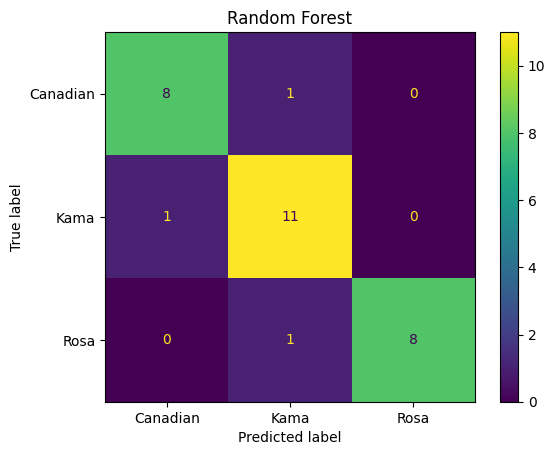

In [47]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions_DT_tunned = modelo_RF_tunned.predict(X_test)
cm_DT_tunned = confusion_matrix(y_test, predictions_DT_tunned, labels=modelo_RF_tunned.classes_)
disp_DT_tunned  = ConfusionMatrixDisplay(confusion_matrix=cm_DT_tunned, display_labels=modelo_RF_tunned.classes_)
disp_DT_tunned.plot()
plt.title('Random Forest')
plt.show()